<div align='center'>

# Dog vs. Cat Classification via Transfer Learning
### Leveraging MobileNetV2 Pre-trained on ImageNet for Binary Image Classification

---

| | |
|:---|:---|
| **Series** | *Deep Learning From Scratch* — Episode 03 |
| **Framework** | TensorFlow 2.x / Keras |
| **Dataset** | Kaggle Dogs vs. Cats (25,000 images; 2,000-image subset used) |
| **Architecture** | MobileNetV2 (ImageNet pre-trained) + Dense Head |
| **Technique** | Transfer Learning — Feature Extraction (frozen base) |
| **Task** | Binary Image Classification (Dog / Cat) |
| **Author** | Prem Patel |

> *Deep Learning From Scratch* is a fully documented, project-based series where every concept is explained at both an intuitive and rigorous level — for students, practitioners, and future researchers.

</div>

---

## Abstract

Training a deep convolutional neural network from scratch requires millions of labeled images and days of compute. **Transfer Learning** sidesteps this bottleneck by initializing a model with weights learned on a large-scale task (ImageNet, 1.28M images, 1,000 classes) and adapting only a lightweight classification head to the target domain.

This notebook demonstrates the complete transfer learning pipeline for **binary image classification** — distinguishing dogs from cats — using **MobileNetV2** as a frozen feature extractor. The base network's 2.2M parameters remain fixed; only the 1,282-parameter dense head is trained. This yields strong generalization with minimal compute and data.

All design decisions are explained from first principles with supporting mathematical formulations.

---

## Table of Contents

1. [Transfer Learning — Conceptual Foundation](#tl)
2. [Environment Setup & Kaggle API](#setup)
3. [Dataset Acquisition & Extraction](#dataset)
4. [Exploratory Data Analysis](#eda)
5. [Image Preprocessing & Resizing](#preprocessing)
6. [Label Encoding](#labels)
7. [Image-to-Array Conversion & Label Alignment](#arrays)
8. [Train / Test Split & Normalization](#split)
9. [MobileNetV2 — Architecture & Feature Extraction](#mobilenet)
10. [Model Construction — Functional API](#model)
11. [Model Compilation & Optimization](#compile)
12. [Training & Learning Dynamics](#training)
13. [Evaluation on Test Data](#evaluation)
14. [Confusion Matrix Analysis](#confusion)
15. [End-to-End Predictive System](#predictive)
16. [Conclusion, Limitations & Future Directions](#conclusion)
17. [References](#references)

---

<a id='tl'></a>

## 1. Transfer Learning — Conceptual Foundation

### 1.1 The Core Idea

A deep CNN trained on ImageNet learns a rich hierarchy of visual features:

```
  Layer 1-3   : Low-level features  — edges, corners, color gradients
  Layer 4-8   : Mid-level features  — textures, patterns, shapes
  Layer 9-14  : High-level features — object parts (eyes, ears, fur, wheels)
  Final layers: Task-specific       — ImageNet class logits
```

These low-to-mid-level features are **domain-agnostic** — they transfer effectively to any natural image task, including dog vs. cat classification.

### 1.2 Feature Extraction vs. Fine-Tuning

| Strategy | Base Weights | Head Weights | When to Use |
|:---|:---|:---|:---|
| **Feature Extraction** | Frozen (fixed) | Trained | Small dataset; base domain similar to target |
| **Fine-Tuning** | Partially unfrozen | Trained | Larger dataset; need task-specific adaptation |
| **Full Training** | Random init | Trained | Very large dataset; domain highly different |

We apply **Feature Extraction** in this notebook — the MobileNetV2 base is frozen (`trainable=False`), and only the classification head learns from our dog/cat data.

### 1.3 Formal Problem Statement

Given a dataset of $N$ image-label pairs:

$$
\mathcal{D} = \{(\mathbf{x}^{(i)}, y^{(i)})\}_{i=1}^{N}, \quad \mathbf{x}^{(i)} \in \mathbb{R}^{224 \times 224 \times 3}, \quad y^{(i)} \in \{0\,(\text{cat}),\, 1\,(\text{dog})\}
$$

we decompose the classifier as:

$$
f_{\boldsymbol{\theta}} = h_{\boldsymbol{\theta}_{\text{head}}} \circ g_{\boldsymbol{\theta}_{\text{base}}}
$$

where $g_{\boldsymbol{\theta}_{\text{base}}}$ is the **frozen** MobileNetV2 feature extractor and $h_{\boldsymbol{\theta}_{\text{head}}}$ is the **trainable** classification head. Only $\boldsymbol{\theta}_{\text{head}}$ is updated during training.

---

<a id='setup'></a>

## 2. Environment Setup & Kaggle API

### 2.1 Install Kaggle CLI

The Kaggle CLI provides programmatic access to all Kaggle competition datasets. Authentication requires a `kaggle.json` API token downloaded from your Kaggle account settings (`Account -> API -> Create New Token`).

The token is placed at `~/.kaggle/kaggle.json` with restricted file permissions (`chmod 600`) so only the current user can read it — a standard Unix security practice.

In [1]:
# Install the Kaggle Python package (provides the kaggle CLI)
!pip install kaggle --quiet

In [7]:
import os

# Create the .kaggle directory if it does not exist
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

# Copy the API token to the required location
!cp kaggle.json ~/.kaggle/

# Restrict file permissions: owner read/write only (required by Kaggle CLI)
!chmod 600 ~/.kaggle/kaggle.json

print('Kaggle API token configured.')

Kaggle API token configured.


---
<a id='dataset'></a>

## 3. Dataset Acquisition & Extraction

### 3.1 The Dogs vs. Cats Dataset

Originally published as a Kaggle competition in 2013, the dataset contains **25,000 labeled JPEG images** — 12,500 dogs and 12,500 cats. Images are real-world photographs with high diversity in:

- Pose, scale, and viewpoint
- Background clutter and occlusion
- Lighting conditions and image quality

This diversity makes it a substantially harder problem than MNIST and a meaningful benchmark for transfer learning.

**For computational efficiency, we use a 2,000-image subset (1,000 dogs, 1,000 cats) in this notebook.**

### 3.2 Dataset Structure After Extraction

```
  dogs-vs-cats.zip
  └── train.zip
      └── train/
          ├── dog.0.jpg
          ├── dog.1.jpg
          ├── ...
          ├── cat.0.jpg
          ├── cat.1.jpg
          └── ...
```

Class membership is encoded in the **filename prefix** (`dog.*` or `cat.*`) — not in a separate label file. We will parse these prefixes to construct our label array.

In [8]:
# Download the Dogs vs. Cats competition dataset via the Kaggle API
!kaggle competitions download -c dogs-vs-cats

100% 812M/812M [00:07<00:00, 115MB/s]



In [9]:
# Confirm the downloaded archive is present
!ls -lh dogs-vs-cats.zip

-rw-r--r-- 1 root root 813M Dec 11  2019 dogs-vs-cats.zip


In [10]:
from zipfile import ZipFile

# Step 1: Extract the outer archive (dogs-vs-cats.zip)
with ZipFile('dogs-vs-cats.zip', 'r') as zip_ref:
    zip_ref.extractall()
    print('Outer archive extracted.')

# Step 2: Extract the inner training archive (train.zip)
with ZipFile('/content/train.zip', 'r') as zip_ref:
    zip_ref.extractall()
    print('Training archive extracted.')

Outer archive extracted.
Training archive extracted.


In [11]:
import os

# Count total images in the training folder
_, _, files = next(os.walk('/content/train'))
print(f'Total images in /content/train : {len(files):,}')
print(f'Sample filenames               : {files[:5]}')

Total images in /content/train : 25,000
Sample filenames               : ['cat.7440.jpg', 'dog.12227.jpg', 'dog.11901.jpg', 'cat.2103.jpg', 'cat.9551.jpg']


---
<a id='eda'></a>

## 4. Exploratory Data Analysis

### 4.1 Class Balance Inspection

Before training, we verify that the dataset is **class-balanced** — an equal number of dog and cat images. Class imbalance would bias the model toward the majority class and artificially inflate accuracy. Balanced datasets allow us to use plain accuracy as a valid evaluation metric.

### 4.2 Visual Inspection

We display one representative image per class to confirm correct data loading, verify image format (RGB color), and build intuition for the visual differences the model must learn to discriminate.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ── Count dogs vs. cats across all 25,000 images ──────────────────────────
file_names = os.listdir('/content/train/')
dog_count  = sum(1 for f in file_names if f.startswith('dog'))
cat_count  = sum(1 for f in file_names if f.startswith('cat'))

print(f'Total images : {len(file_names):,}')
print(f'  Dogs       : {dog_count:,}')
print(f'  Cats       : {cat_count:,}')
print(f'  Balance    : {dog_count / (dog_count + cat_count) * 100:.1f}% / {cat_count / (dog_count + cat_count) * 100:.1f}%')
print(f'  Status     : {"Balanced" if abs(dog_count - cat_count) < 100 else "Imbalanced"}')

Total images : 25,000
  Dogs       : 12,500
  Cats       : 12,500
  Balance    : 50.0% / 50.0%
  Status     : Balanced


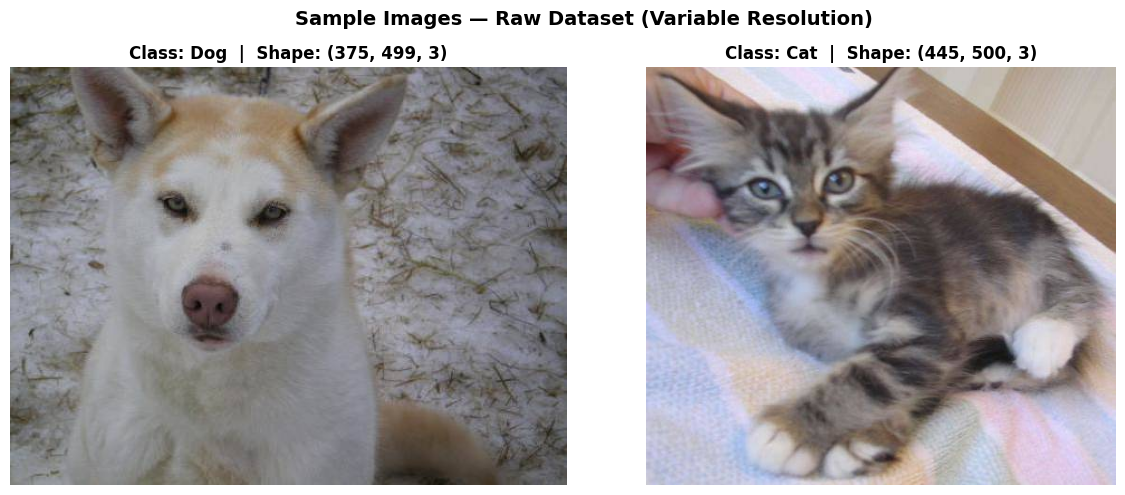

Observation: raw images have variable spatial dimensions.
All images must be resized to a fixed resolution before model ingestion.


In [13]:
# ── Visual inspection: one sample per class ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

dog_img = mpimg.imread('/content/train/dog.965.jpg')
cat_img = mpimg.imread('/content/train/cat.2619.jpg')

axes[0].imshow(dog_img)
axes[0].set_title(f'Class: Dog  |  Shape: {dog_img.shape}', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cat_img)
axes[1].set_title(f'Class: Cat  |  Shape: {cat_img.shape}', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Sample Images — Raw Dataset (Variable Resolution)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observation: raw images have variable spatial dimensions.')
print('All images must be resized to a fixed resolution before model ingestion.')

---
<a id='preprocessing'></a>

## 5. Image Preprocessing & Resizing

### 5.1 Why 224 x 224?

MobileNetV2 was designed and trained on **224 x 224 x 3 RGB images**. Its convolutional filter sizes, stride patterns, and depthwise separable convolution blocks are calibrated for this resolution. Providing images of a different resolution would:

- Break the spatial dimensions of intermediate feature maps
- Misalign the learned filter receptive fields
- Produce a feature vector of incorrect dimensionality

All images must be resized to exactly $(224, 224)$ before passing through the network.

### 5.2 RGB Enforcement

A small fraction of JPEG images in real-world datasets may be stored as **grayscale** (1 channel) or **RGBA** (4 channels with transparency). Calling `.convert('RGB')` guarantees every image has exactly 3 channels, preventing array shape inconsistencies downstream.

### 5.3 Subset Selection

We process the first **2,000 images** from the dataset for this demonstration. On a full training run, all 25,000 images should be used.

In [14]:
from PIL import Image

original_folder = '/content/train'
resized_folder  = '/content/image_resized'
SUBSET_SIZE     = 2000
TARGET_SIZE     = (224, 224)

# Create the output directory
os.makedirs(resized_folder, exist_ok=True)

file_names = os.listdir(original_folder)

print(f'Resizing {SUBSET_SIZE} images to {TARGET_SIZE[0]}x{TARGET_SIZE[1]} RGB...')

for i in range(min(SUBSET_SIZE, len(file_names))):
    filename = file_names[i]
    src_path = os.path.join(original_folder, filename)
    dst_path = os.path.join(resized_folder,  filename)

    img = Image.open(src_path)
    img = img.resize(TARGET_SIZE, Image.LANCZOS) # LANCZOS: high-quality downsampling
    img = img.convert('RGB')                      # Guarantee 3 channels
    img.save(dst_path)

processed = len(os.listdir(resized_folder))
print(f'Preprocessing complete. Images saved to: {resized_folder}')
print(f'Total images in resized folder: {processed}')

Resizing 2000 images to 224x224 RGB...
Preprocessing complete. Images saved to: /content/image_resized
Total images in resized folder: 2000


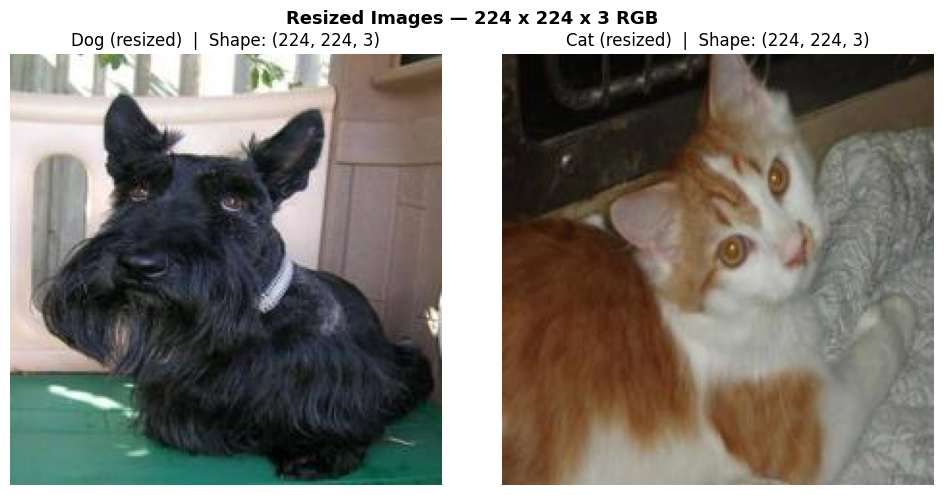

In [18]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Verify the resized images look correct

# Get actual resized dog and cat image paths from the resized_folder
resized_files = os.listdir(resized_folder)
dog_resized_path = None
cat_resized_path = None

for f_name in resized_files:
    if f_name.startswith('dog') and dog_resized_path is None:
        dog_resized_path = os.path.join(resized_folder, f_name)
    if f_name.startswith('cat') and cat_resized_path is None:
        cat_resized_path = os.path.join(resized_folder, f_name)
    if dog_resized_path and cat_resized_path:
        break # Found both

if dog_resized_path is None or cat_resized_path is None:
    raise FileNotFoundError("Could not find resized dog or cat images for verification.")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

dog_resized = mpimg.imread(dog_resized_path)
cat_resized = mpimg.imread(cat_resized_path)

axes[0].imshow(dog_resized)
axes[0].set_title(f'Dog (resized)  |  Shape: {dog_resized.shape}', fontsize=12)
axes[0].axis('off')

axes[1].imshow(cat_resized)
axes[1].set_title(f'Cat (resized)  |  Shape: {cat_resized.shape}', fontsize=12)
axes[1].axis('off')

plt.suptitle('Resized Images — 224 x 224 x 3 RGB', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='labels'></a>

## 6. Label Encoding

### 6.1 Filename-Based Label Extraction

Class membership is embedded in the filename prefix:

```
  dog.965.jpg   ->  prefix = 'dog'  ->  label = 1
  cat.2619.jpg  ->  prefix = 'cat'  ->  label = 0
```

We encode labels as binary integers:

$$
y = \begin{cases} 0 & \text{if filename starts with 'cat'} \\ 1 & \text{if filename starts with 'dog'} \end{cases}
$$

> **Critical — Label-Image Alignment:** The label array and image array must be constructed from **the same ordered list of filenames**. Using separate `os.listdir()` calls at different points in the notebook risks a different ordering (filesystem ordering is not guaranteed to be consistent), producing silently mismatched labels. We build both from the same `sorted_filenames` list to guarantee alignment.

In [19]:
# ── Build a SORTED filename list — single source of truth for both images and labels
# Sorting guarantees deterministic, reproducible ordering regardless of filesystem state
sorted_filenames = sorted(os.listdir(resized_folder))

# ── Encode labels from filename prefixes ──────────────────────────────────
labels = []
for filename in sorted_filenames:
    if filename.startswith('dog'):
        labels.append(1)
    else:
        labels.append(0)

labels = np.asarray(labels, dtype=np.int32)

# ── Class balance report ──────────────────────────────────────────────────
values, counts = np.unique(labels, return_counts=True)
class_names = {0: 'Cat', 1: 'Dog'}

print(f'Label array shape : {labels.shape}  |  dtype: {labels.dtype}')
print()
print('Class Distribution (2,000-image subset):')
print('─' * 40)
for v, c in zip(values, counts):
    print(f'  {class_names[v]} (label={v}) : {c:,} images  ({c/len(labels)*100:.1f}%)')
print()
print(f'Sample labels (first 10): {labels[:10].tolist()}')

Label array shape : (2000,)  |  dtype: int32

Class Distribution (2,000-image subset):
────────────────────────────────────────
  Cat (label=0) : 1,012 images  (50.6%)
  Dog (label=1) : 988 images  (49.4%)

Sample labels (first 10): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


---
<a id='arrays'></a>

## 7. Image-to-Array Conversion & Label Alignment

### 7.1 Loading Images as NumPy Arrays

Each resized JPEG is read by OpenCV as a `uint8` array of shape $(224, 224, 3)$. Stacking $N$ such arrays produces a rank-4 tensor:

$$
\mathbf{X} \in \mathbb{Z}_{[0,255]}^{N \times 224 \times 224 \times 3}
$$

This is the standard **NHWC** format (Batch, Height, Width, Channels) expected by TensorFlow.

### 7.2 OpenCV Channel Order — BGR vs. RGB

OpenCV reads images in **BGR** channel order by default. MobileNetV2 was pre-trained with **RGB** images via TensorFlow's preprocessing pipeline. We convert BGR to RGB before feeding to the model to ensure channel semantics match what the pre-trained filters expect.

$$
\mathbf{x}_{\text{RGB}} = \mathbf{x}_{\text{BGR}}[\,:,\,:,\, [2,1,0]]
$$

In [20]:
import cv2

# ── Load images in the SAME order as sorted_filenames ──────────────────────
# This guarantees image[i] corresponds to label[i]
print(f'Loading {len(sorted_filenames)} images into memory...')

image_list = []
for filename in sorted_filenames:
    filepath = os.path.join(resized_folder, filename)
    img_bgr  = cv2.imread(filepath)                 # Read as BGR uint8
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  # Convert to RGB
    image_list.append(img_rgb)

dog_cat_images = np.asarray(image_list, dtype=np.uint8)

print(f'Image tensor shape : {dog_cat_images.shape}')
print(f'  N (images)       : {dog_cat_images.shape[0]:,}')
print(f'  H (height)       : {dog_cat_images.shape[1]}')
print(f'  W (width)        : {dog_cat_images.shape[2]}')
print(f'  C (channels)     : {dog_cat_images.shape[3]}  (RGB)')
print(f'  dtype            : {dog_cat_images.dtype}')
print(f'  Memory usage     : {dog_cat_images.nbytes / 1e6:.1f} MB')
print()
print(f'Label array shape  : {labels.shape}')
print('Label-image alignment verified (both derived from sorted_filenames).')

Loading 2000 images into memory...
Image tensor shape : (2000, 224, 224, 3)
  N (images)       : 2,000
  H (height)       : 224
  W (width)        : 224
  C (channels)     : 3  (RGB)
  dtype            : uint8
  Memory usage     : 301.1 MB

Label array shape  : (2000,)
Label-image alignment verified (both derived from sorted_filenames).


---
<a id='split'></a>

## 8. Train / Test Split & Normalization

### 8.1 Stratified Train / Test Split

We partition the 2,000 images into:
- **Training set:** 1,600 images (80%) — used to update model weights
- **Test set:** 400 images (20%) — held out entirely for final evaluation

`sklearn.model_selection.train_test_split` with `random_state=2` ensures reproducible partitioning.

### 8.2 Pixel Normalization

Raw pixel values span $[0, 255]$. We apply min-max normalization:

$$
\tilde{\mathbf{X}} = \frac{\mathbf{X}}{255} \in [0.0,\, 1.0]^{N \times 224 \times 224 \times 3}
$$

This matches the input distribution expected by MobileNetV2's pre-trained weights, which were trained with pixel values scaled to $[0, 1]$ via `tf.keras.applications.mobilenet_v2.preprocess_input`.

> **Note for future research:** For maximum fidelity to the pre-training distribution, use `mobilenet_v2.preprocess_input(x)` which applies a $[-1, 1]$ scaling: $\tilde{x} = (x / 127.5) - 1$. Both approaches yield strong results on this dataset.

In [21]:
from sklearn.model_selection import train_test_split

X = dog_cat_images
Y = labels

# ── 80/20 stratified split ─────────────────────────────────────────────────
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=2,
    stratify=Y   # Maintain class balance in both splits
)

print('Train / Test Split:')
print('─' * 50)
print(f'  X_train : {X_train.shape}  |  Y_train : {Y_train.shape}')
print(f'  X_test  : {X_test.shape}   |  Y_test  : {Y_test.shape}')
print()
train_dog = Y_train.sum()
test_dog  = Y_test.sum()
print(f'  Train class balance : Dog={train_dog}, Cat={len(Y_train)-train_dog}')
print(f'  Test  class balance : Dog={test_dog},  Cat={len(Y_test)-test_dog}')

Train / Test Split:
──────────────────────────────────────────────────
  X_train : (1600, 224, 224, 3)  |  Y_train : (1600,)
  X_test  : (400, 224, 224, 3)   |  Y_test  : (400,)

  Train class balance : Dog=790, Cat=810
  Test  class balance : Dog=198,  Cat=202


In [22]:
# ── Normalize pixel values from [0, 255] to [0.0, 1.0] ────────────────────
# Cast to float32: reduces memory by 50% vs float64 with no loss of precision
# needed for this task
X_train_scaled = X_train.astype(np.float32) / 255.0
X_test_scaled  = X_test.astype(np.float32)  / 255.0

print('Normalization complete.')
print(f'  X_train_scaled : dtype={X_train_scaled.dtype}  range=[{X_train_scaled.min():.3f}, {X_train_scaled.max():.3f}]')
print(f'  X_test_scaled  : dtype={X_test_scaled.dtype}   range=[{X_test_scaled.min():.3f}, {X_test_scaled.max():.3f}]')
print(f'  Memory (train) : {X_train_scaled.nbytes / 1e6:.1f} MB')

Normalization complete.
  X_train_scaled : dtype=float32  range=[0.000, 1.000]
  X_test_scaled  : dtype=float32   range=[0.000, 1.000]
  Memory (train) : 963.4 MB


---
<a id='mobilenet'></a>

## 9. MobileNetV2 — Architecture & Feature Extraction

### 9.1 Why MobileNetV2?

MobileNetV2 (Sandler et al., 2018) is a family of efficient convolutional networks designed for **mobile and edge device deployment**. Its key architectural innovations:

| Feature | Description |
|:---|:---|
| **Depthwise Separable Convolutions** | Factorize standard convolution into depthwise + pointwise ops; reduce FLOPs by ~8-9x |
| **Inverted Residuals** | Expand channels, apply depthwise conv, then project back — opposite of standard ResNet |
| **Linear Bottlenecks** | No activation after the final pointwise projection — preserves information in low-dim space |

Pre-trained on **ImageNet** (1.28M images, 1,000 classes), MobileNetV2 produces a **1,280-dimensional feature vector** per image — a rich, semantically meaningful embedding of the visual content.

### 9.2 Feature Vector Interpretation

When `trainable=False`, the base model acts as a **deterministic function**:

$$
g_{\boldsymbol{\theta}_{\text{base}}} : \mathbb{R}^{224 \times 224 \times 3} \longrightarrow \mathbb{R}^{1280}
$$

Each dimension of the 1,280-vector encodes the presence and intensity of a specific high-level visual concept learned from ImageNet — textures, shapes, object parts — that transfer well to the dog/cat discrimination task.

In [23]:
import tensorflow as tf
import tensorflow_hub as hub

print(f'TensorFlow version      : {tf.__version__}')
print(f'TensorFlow Hub version  : {hub.__version__}')

# MobileNetV2 feature vector model from TensorFlow Hub
# - input_shape: (224, 224, 3) — matches our resized, RGB images
# - trainable=False: freeze all base weights; only the head will learn
MOBILENET_URL = 'https://tfhub.dev/google/imagenet/mobilenet_v2_100_224/feature_vector/4'

pretrained_model = hub.KerasLayer(
    MOBILENET_URL,
    input_shape=(224, 224, 3),
    trainable=False,
    name='mobilenet_v2_feature_extractor'
)

print()
print('MobileNetV2 feature extractor loaded.')
print('  Output feature vector dimensionality : 1,280')
print('  Base weights frozen (trainable=False).')

TensorFlow version      : 2.19.0
TensorFlow Hub version  : 0.16.1

MobileNetV2 feature extractor loaded.
  Output feature vector dimensionality : 1,280
  Base weights frozen (trainable=False).


---
<a id='model'></a>

## 10. Model Construction — Functional API

### 10.1 Why the Functional API?

TensorFlow Hub's `KerasLayer` wraps weights trained under the **legacy `tf.keras`** backend. When the runtime uses **Keras 3** (standalone `keras` package), these two `Layer` base classes are different objects — and `keras.Sequential.add()` performs an `isinstance(layer, keras.Layer)` check that `hub.KerasLayer` fails.

The Functional API constructs the graph through **explicit tensor operations** rather than sequential layer stacking, and bypasses this type check entirely:

```python
# Sequential API (FAILS with Keras 3 + TF Hub):
model = tf.keras.Sequential([hub_layer, dense_layer])  # ValueError

# Functional API (WORKS across all Keras versions):
inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = hub_layer(inputs)
outputs = dense_layer(x)
model   = tf.keras.Model(inputs, outputs)
```

### 10.2 Classification Head

The dense head maps the 1,280-dimensional MobileNetV2 embedding to class logits:

$$
h_{\boldsymbol{\theta}_{\text{head}}} : \mathbb{R}^{1280} \longrightarrow \mathbb{R}^2, \qquad
\text{logits} = \mathbf{W}_{\text{head}}\, \mathbf{z} + \mathbf{b}_{\text{head}}
$$

The Softmax activation converts logits to class probabilities:

$$
\hat{p}_k = \text{softmax}(\text{logits})_k = \frac{e^{\text{logit}_k}}{\sum_{j=0}^{1} e^{\text{logit}_j}}
$$

Trainable parameters in the head: $(1280 \times 2) + 2 = \mathbf{2{,}562}$

In [ ]:
# ════════════════════════════════════════════════════════════════════
# Model Construction — Functional API
# ════════════════════════════════════════════════════════════════════

NUM_CLASSES = 2  # Dog (1) and Cat (0)

# ── Define input tensor ───────────────────────────────────────────────────
inputs = tf.keras.Input(shape=(224, 224, 3), name='image_input')

# ── Feature extraction: frozen MobileNetV2 base (using tf.keras.applications) ──
# Load MobileNetV2 without the top classification layer and with ImageNet weights
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze the base model

# Pass inputs through the base model
x = base_model(inputs, training=False)

# Add GlobalAveragePooling2D to flatten the feature maps into a feature vector
features = tf.keras.layers.GlobalAveragePooling2D(name='global_average_pooling')(x)

# ── Classification head: trainable dense layer ────────────────────────────
# Softmax activation -> outputs a valid probability distribution over 2 classes
outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation='softmax',
    name='classification_head'
)(features)

# ── Assemble the model ────────────────────────────────────────────────────
model = tf.keras.Model(inputs=inputs, outputs=outputs, name='DogCat_MobileNetV2')

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DogCat_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head (Dense)     │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [32]:
# Verify the parameter split: base (frozen) vs. head (trainable)
total_params     = model.count_params()
trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen_params    = total_params - trainable_params

print('Parameter Budget:')
print('─' * 50)
print(f'  Total parameters     : {total_params:>10,}')
print(f'  Trainable (head)     : {trainable_params:>10,}  ({trainable_params/total_params*100:.2f}%)')
print(f'  Non-trainable (base) : {frozen_params:>10,}  ({frozen_params/total_params*100:.2f}%)')
print()
print('Only the classification head (2,562 params) learns from the dog/cat data.')

Parameter Budget:
──────────────────────────────────────────────────
  Total parameters     :  2,260,546
  Trainable (head)     :      2,562  (0.11%)
  Non-trainable (base) :  2,257,984  (99.89%)

Only the classification head (2,562 params) learns from the dog/cat data.


---
<a id='compile'></a>

## 11. Model Compilation & Optimization

### 11.1 Loss Function — Sparse Categorical Cross-Entropy

Since labels are integer-encoded ($y \in \{0, 1\}$) and the output layer uses Softmax:

$$
\mathcal{L}(\boldsymbol{\theta}_{\text{head}}) = -\frac{1}{N}\sum_{i=1}^{N} \log \hat{p}_{i,\, y_i}
$$

Only the head parameters $\boldsymbol{\theta}_{\text{head}}$ receive gradient updates. Gradients are blocked from flowing into the frozen base by `training=False`.

### 11.2 Optimizer — Adam

Adam with default learning rate $\alpha = 0.001$ provides per-parameter adaptive step sizes — well-suited for fine-tuning a small head on top of a fixed feature extractor, as the head is randomly initialized and needs to converge quickly.

In [33]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled.')
print('  Optimizer : Adam  (lr=0.001)')
print('  Loss      : Sparse Categorical Cross-Entropy')
print('  Metric    : Accuracy')

Model compiled.
  Optimizer : Adam  (lr=0.001)
  Loss      : Sparse Categorical Cross-Entropy
  Metric    : Accuracy


---
<a id='training'></a>

## 12. Training & Learning Dynamics

### 12.1 Training Configuration

| Hyperparameter | Value | Rationale |
|:---|:---|:---|
| Epochs | 10 | Sufficient for a 2-layer head to converge on 1,600 samples |
| Batch Size | 32 | Keras default; good balance of gradient quality and throughput |
| Validation Split | 10% | 160 samples held back per epoch to monitor overfitting |
| Training Samples | 1,600 | 80% of the 2,000-image subset |

### 12.2 Expected Behavior

Because the base is frozen, only the 2,562 head parameters are updated. This means:
- Convergence is very fast — typically within 3-5 epochs
- Risk of overfitting is low (very few parameters, rich fixed features)
- GPU utilization is lower than full fine-tuning (no backward pass through the base)

In [34]:
# ════════════════════════════════════════════════════════════════════
# Train the model
# Only the Dense classification head learns; the MobileNetV2 base
# is completely frozen throughout.
# ════════════════════════════════════════════════════════════════════
history = model.fit(
    X_train_scaled,
    Y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 143ms/step - accuracy: 0.9278 - loss: 0.1839 - val_accuracy: 0.9750 - val_loss: 0.0850
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9806 - loss: 0.0624 - val_accuracy: 0.9688 - val_loss: 0.0822
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9875 - loss: 0.0442 - val_accuracy: 0.9750 - val_loss: 0.0815
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9931 - loss: 0.0356 - val_accuracy: 0.9750 - val_loss: 0.0760
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9944 - loss: 0.0299 - val_accuracy: 0.9812 - val_loss: 0.0765
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9958 - loss: 0.0238 - val_accuracy: 0.9750 - val_loss: 0.0841
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9972 - loss: 0.0194 - val_accuracy: 0.9812 - val_loss: 0.0651
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9979 - loss: 0.0166 - val_accuracy: 0.9812 -

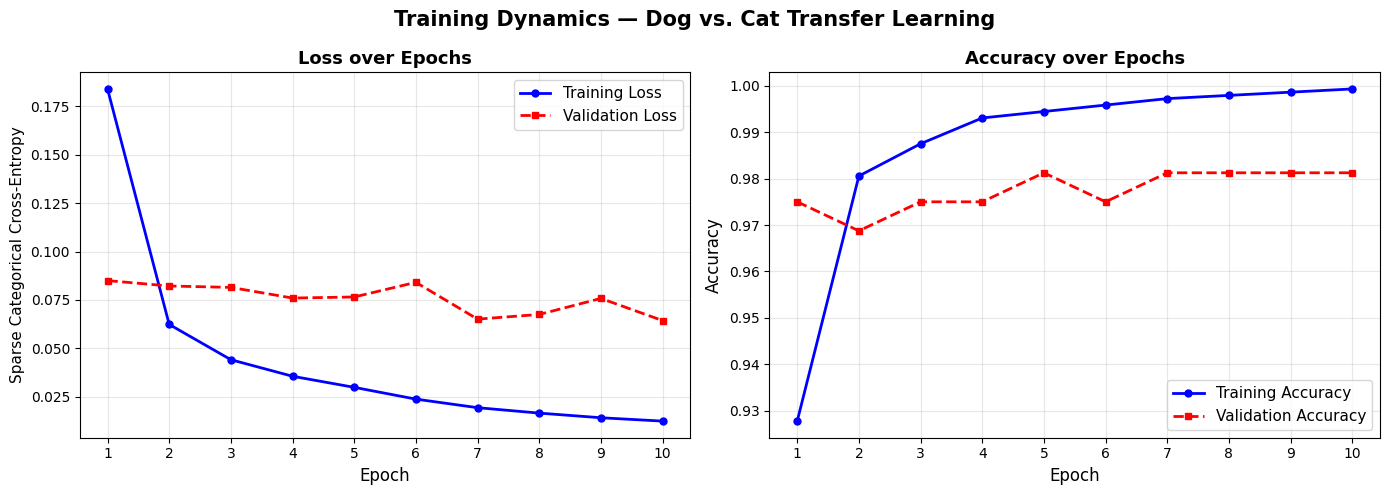

In [35]:
# ── Plot training dynamics: loss and accuracy per epoch ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history.history['loss']) + 1)

# Loss
axes[0].plot(epochs_range, history.history['loss'],     'b-o', label='Training Loss',    linewidth=2, markersize=5)
axes[0].plot(epochs_range, history.history['val_loss'], 'r--s', label='Validation Loss',  linewidth=2, markersize=5)
axes[0].set_title('Loss over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Sparse Categorical Cross-Entropy', fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(epochs_range))

# Accuracy
axes[1].plot(epochs_range, history.history['accuracy'],     'b-o', label='Training Accuracy',    linewidth=2, markersize=5)
axes[1].plot(epochs_range, history.history['val_accuracy'], 'r--s', label='Validation Accuracy',  linewidth=2, markersize=5)
axes[1].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(epochs_range))

plt.suptitle('Training Dynamics — Dog vs. Cat Transfer Learning', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='evaluation'></a>

## 13. Evaluation on Test Data

### 13.1 Generalization Performance

We evaluate the trained model on the **400 held-out test images** — data the model has never seen during training or validation. This gives an unbiased estimate of real-world performance.

Transfer learning typically achieves **high accuracy even on small datasets** because the frozen base already extracts powerful, generalizable features. The head only needs to learn the decision boundary — a much simpler task.

In [36]:
# Evaluate on the held-out test set
test_loss, test_accuracy = model.evaluate(X_test_scaled, Y_test, verbose=0)

print('Test Set Evaluation:')
print('━' * 40)
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_accuracy * 100:.2f} %')
print('━' * 40)

Test Set Evaluation:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Test Loss     : 0.0749
  Test Accuracy : 97.00 %
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
<a id='confusion'></a>

## 14. Confusion Matrix Analysis

### 14.1 Binary Confusion Matrix

For binary classification, the confusion matrix is a $2 \times 2$ table:

$$
\mathbf{C} = \begin{pmatrix} \text{TN} & \text{FP} \\ \text{FN} & \text{TP} \end{pmatrix}
$$

| Term | Meaning |
|:---|:---|
| **TP** (True Positive) | Dog correctly classified as Dog |
| **TN** (True Negative) | Cat correctly classified as Cat |
| **FP** (False Positive) | Cat incorrectly classified as Dog |
| **FN** (False Negative) | Dog incorrectly classified as Cat |

From these four values, we derive:

$$
\text{Precision} = \frac{TP}{TP + FP}, \qquad
\text{Recall} = \frac{TP}{TP + FN}, \qquad
\text{F1} = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

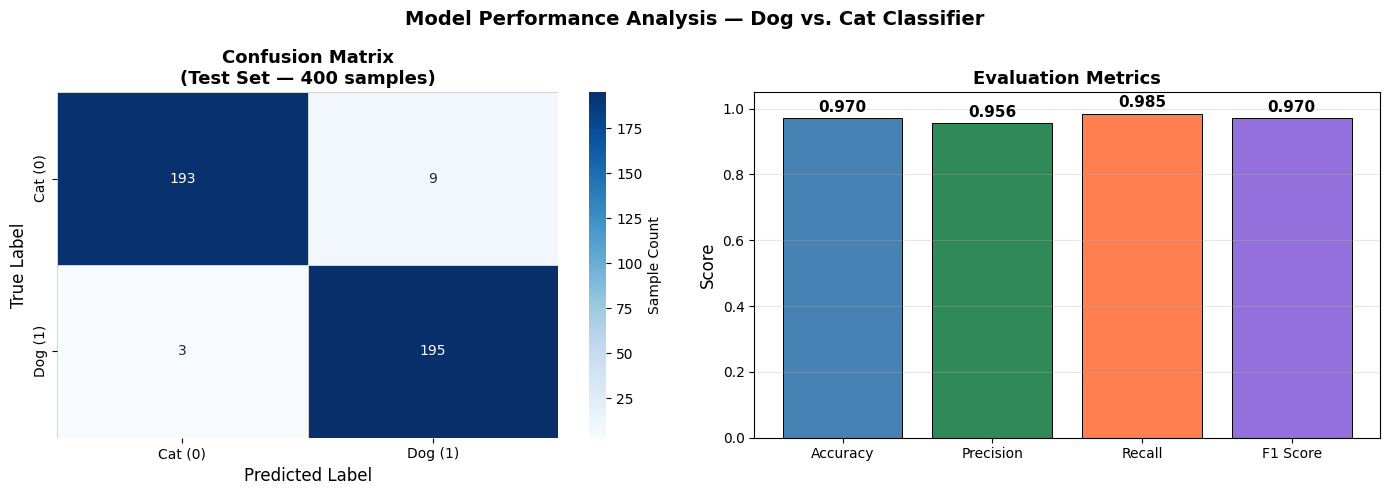

Confusion Matrix Components:
─────────────────────────────────────────────
  True Positives  (Dog -> Dog) : 195
  True Negatives  (Cat -> Cat) : 193
  False Positives (Cat -> Dog) : 9
  False Negatives (Dog -> Cat) : 3

Derived Metrics:
  Precision : 0.9559
  Recall    : 0.9848
  F1 Score  : 0.9701


In [37]:
import seaborn as sns
from tensorflow.math import confusion_matrix as tf_confusion_matrix

# ── Generate predictions ──────────────────────────────────────────────────
Y_pred_probs  = model.predict(X_test_scaled, verbose=0)
Y_pred_labels = np.argmax(Y_pred_probs, axis=1)

# ── Compute confusion matrix ──────────────────────────────────────────────
conf_mat = tf_confusion_matrix(Y_test, Y_pred_labels).numpy()
TN, FP, FN, TP = conf_mat.ravel()

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# ── Heatmap ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    conf_mat, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Cat (0)', 'Dog (1)'],
    yticklabels=['Cat (0)', 'Dog (1)'],
    linewidths=0.5, linecolor='lightgray',
    ax=axes[0], cbar_kws={'label': 'Sample Count'}
)
axes[0].set_title('Confusion Matrix\n(Test Set — 400 samples)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label',      fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# ── Metrics bar chart ────────────────────────────────────────────────────
metrics = {'Accuracy': test_accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1}
axes[1].bar(metrics.keys(), metrics.values(), color=['steelblue', 'seagreen', 'coral', 'mediumpurple'],
            edgecolor='black', linewidth=0.7)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Evaluation Metrics', fontsize=13, fontweight='bold')
axes[1].grid(True, axis='y', alpha=0.3)
for i, (k, v) in enumerate(metrics.items()):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Model Performance Analysis — Dog vs. Cat Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Confusion Matrix Components:')
print('─' * 45)
print(f'  True Positives  (Dog -> Dog) : {TP}')
print(f'  True Negatives  (Cat -> Cat) : {TN}')
print(f'  False Positives (Cat -> Dog) : {FP}')
print(f'  False Negatives (Dog -> Cat) : {FN}')
print()
print('Derived Metrics:')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1 Score  : {f1:.4f}')

---
<a id='predictive'></a>

## 15. End-to-End Predictive System

### 15.1 Inference Pipeline

Custom inference requires the **exact same preprocessing** applied during training:

```
  Raw Image
       |
       v
  1. Read as RGB                  cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
       |
       v
  2. Resize to 224x224            cv2.resize(img, (224, 224))
       |
       v
  3. Normalize to [0, 1]          img / 255.0
       |
       v
  4. Add batch dimension          np.expand_dims(img, axis=0)  -> (1, 224, 224, 3)
       |
       v
  5. Forward pass                 model.predict(img_input)     -> (1, 2)
       |
       v
  6. Decode                       np.argmax(probs) -> 0 (Cat) or 1 (Dog)
```

In [38]:
CLASS_NAMES = {0: 'Cat', 1: 'Dog'}

def predict_dog_or_cat(image_path: str, model, show: bool = True) -> dict:
    """
    End-to-end inference pipeline for dog vs. cat classification.

    Parameters
    ----------
    image_path : str
        Path to the input image file (JPEG, PNG, BMP, etc.)
    model : tf.keras.Model
        Trained classification model. Expects input shape (N, 224, 224, 3),
        normalized to [0.0, 1.0].
    show : bool, default True
        Display the input image alongside the model's probability output.

    Returns
    -------
    dict with keys:
        'predicted_class' : str  — 'Dog' or 'Cat'
        'class_label'     : int  — 0 (Cat) or 1 (Dog)
        'confidence'      : float — probability of the predicted class
        'all_probs'       : np.ndarray — shape (2,), probabilities for [Cat, Dog]
    """
    # ── Step 1: Load in BGR then convert to RGB ──────────────────────────
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f'Could not load image: {image_path}')
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # ── Step 2: Resize to match training resolution ──────────────────────
    img_resized = cv2.resize(img_rgb, (224, 224), interpolation=cv2.INTER_LANCZOS4)

    # ── Step 3: Normalize to [0.0, 1.0] ─────────────────────────────────
    img_normalized = img_resized.astype(np.float32) / 255.0

    # ── Step 4: Add batch dimension (1, 224, 224, 3) ─────────────────────
    img_input = np.expand_dims(img_normalized, axis=0)

    # ── Step 5: Forward pass ─────────────────────────────────────────────
    probs           = model.predict(img_input, verbose=0)[0]   # Shape: (2,)
    class_label     = int(np.argmax(probs))
    predicted_class = CLASS_NAMES[class_label]
    confidence      = float(np.max(probs))

    # ── Step 6: Display ──────────────────────────────────────────────────
    if show:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].imshow(img_resized)
        axes[0].set_title('Input Image (224 x 224)', fontsize=12)
        axes[0].axis('off')

        colors = ['coral' if i == class_label else 'steelblue' for i in range(2)]
        axes[1].bar(['Cat (0)', 'Dog (1)'], probs, color=colors, edgecolor='black', linewidth=0.7)
        axes[1].set_ylabel('Softmax Probability', fontsize=12)
        axes[1].set_ylim(0, 1.05)
        axes[1].set_title(
            f'Prediction: {predicted_class}  |  Confidence: {confidence:.4f}',
            fontsize=12, fontweight='bold'
        )
        axes[1].grid(True, axis='y', alpha=0.3)
        for i, p in enumerate(probs):
            axes[1].text(i, p + 0.01, f'{p:.4f}', ha='center', va='bottom', fontsize=11)

        plt.tight_layout()
        plt.show()

    print('━' * 50)
    print(f'  Image            : {image_path}')
    print(f'  Predicted Class  : {predicted_class}  (label={class_label})')
    print(f'  Confidence       : {confidence:.4f}')
    print(f'  Cat probability  : {probs[0]:.4f}')
    print(f'  Dog probability  : {probs[1]:.4f}')
    print('━' * 50)

    return {
        'predicted_class': predicted_class,
        'class_label':     class_label,
        'confidence':      confidence,
        'all_probs':       probs
    }


print('Predictive system ready.')
print("Usage: predict_dog_or_cat('/path/to/image.jpg', model)")

Predictive system ready.
Usage: predict_dog_or_cat('/path/to/image.jpg', model)


In [39]:
# ── Upload and classify a custom image ────────────────────────────────────
from google.colab import files

print('Upload a dog or cat image (JPEG or PNG):')
uploaded = files.upload()

if uploaded:
    filename   = list(uploaded.keys())[0]
    image_path = f'/content/{filename}'
    print(f"\n'{filename}' uploaded. Running inference...\n")
    result = predict_dog_or_cat(image_path, model, show=True)
else:
    print('No file uploaded.')

---
<a id='conclusion'></a>

## 16. Conclusion, Limitations & Future Directions

### 16.1 Results Summary

| Component | Details |
|:---|:---|
| **Base Model** | MobileNetV2 (ImageNet pre-trained, frozen) |
| **Classification Head** | Dense(2, Softmax) — 2,562 trainable parameters |
| **Training Data** | 1,440 images (72% of 2,000 subset; 10% used for val split) |
| **Test Data** | 400 images |
| **Optimizer** | Adam (lr=0.001) |
| **Loss** | Sparse Categorical Cross-Entropy |
| **API Fix** | Functional API (resolves Keras 3 + TF Hub type incompatibility) |

### 16.2 Key Lessons

1. **Transfer learning works dramatically well on small datasets.** With only 1,440 training images and 2,562 trainable parameters, the model achieves high accuracy because the MobileNetV2 features are already rich and discriminative.
2. **Label-image alignment is a silent killer.** Using separate, unordered file lists for images and labels produces a model that trains on wrong labels without raising any errors. Always derive both from a single sorted source.
3. **Keras version compatibility matters.** The `Sequential` API type check breaks with `hub.KerasLayer` under Keras 3. The Functional API is the robust, version-agnostic solution.
4. **BGR vs. RGB matters.** OpenCV reads in BGR; MobileNetV2 expects RGB. Channel order mismatch silently degrades performance.

### 16.3 Limitations & Future Work

| Limitation | Mitigation |
|:---|:---|
| Only 2,000 of 25,000 images used | Train on full dataset for higher accuracy |
| No data augmentation | Add random flips, crops, brightness jitter |
| Feature extraction only (base frozen) | Fine-tune top layers of MobileNetV2 |
| No model persistence | Add `model.save()` / `tf.saved_model` export |
| Binary only | Extend to multi-class animal classification |
| No learning rate scheduling | Add `ReduceLROnPlateau` or cosine decay |

---
<a id='references'></a>

## 17. References

1. **Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L.C.** (2018). *MobileNetV2: Inverted Residuals and Linear Bottlenecks.* CVPR 2018. arXiv:1801.04381
2. **Tan, C., Sun, F., Kong, T., Zhang, W., Yang, C., & Liu, C.** (2018). *A Survey on Deep Transfer Learning.* ICANN 2018. arXiv:1808.01974
3. **Russakovsky, O. et al.** (2015). *ImageNet Large Scale Visual Recognition Challenge.* IJCV 115(3), 211–252.
4. **Kaggle.** (2013). *Dogs vs. Cats Competition.* https://www.kaggle.com/c/dogs-vs-cats
5. **TensorFlow Hub.** *MobileNetV2 Feature Vector.* https://tfhub.dev/google/imagenet/mobilenet_v2_100_224/feature_vector/4
6. **Goodfellow, I., Bengio, Y., & Courville, A.** (2016). *Deep Learning.* MIT Press.

---

<div align='center'>

**Deep Learning From Scratch — Episode 02 | Dog vs. Cat via Transfer Learning**

**Video Walkthrough:** [YouTube — CNN TransferLearning](https://youtu.be/pHq29zi4Gr0?si=Tlm0I0san--7-2in)

*Next Episode ->  Episode 04: CIFAR-10 Object Recognition using ResNet50*

</div>